<h1 style="text-align:center;">SHOPPING TRENDS ANALYSIS</h1>

<h2 style="text-align:center;">Python Data Analytics Project </h2>

### Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load CSV

In [16]:
file_path = "C:\Projects\Excel Files\shopping_trends_updated.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Data Structure Understanding

#### Check Dataset Size

In [17]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 3900
Number of Columns: 18


#### View First 5 Records

In [18]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


#### View Last 5 Records

In [19]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


#### Basic Information

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

#### Column Names

In [21]:
df.columns.tolist()

['Customer ID',
 'Age',
 'Gender',
 'Item Purchased',
 'Category',
 'Purchase Amount (USD)',
 'Location',
 'Size',
 'Color',
 'Season',
 'Review Rating',
 'Subscription Status',
 'Shipping Type',
 'Discount Applied',
 'Promo Code Used',
 'Previous Purchases',
 'Payment Method',
 'Frequency of Purchases']

#### Unique values for every column

In [22]:
for column in df.columns:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique())


Customer ID
Unique values: 3900

Age
Unique values: 53

Gender
Unique values: 2

Item Purchased
Unique values: 25

Category
Unique values: 4

Purchase Amount (USD)
Unique values: 81

Location
Unique values: 50

Size
Unique values: 4

Color
Unique values: 25

Season
Unique values: 4

Review Rating
Unique values: 26

Subscription Status
Unique values: 2

Shipping Type
Unique values: 6

Discount Applied
Unique values: 2

Promo Code Used
Unique values: 2

Previous Purchases
Unique values: 50

Payment Method
Unique values: 6

Frequency of Purchases
Unique values: 7


#### Numerical columns

In [23]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numeric_columns.tolist())

Numerical Columns:
['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']


#### Categorical columns

In [24]:
categorical_columns = df.select_dtypes(include=["str"]).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']


#### Customer ID uniqueness

In [25]:
if df["Customer ID"].nunique() == len(df):
    print("Customer ID is unique for every record.")
else:
    print("Duplicate Customer IDs are present.")

Customer ID is unique for every record.


#### Numerical summary

In [26]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,1950.500000,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,44.068462,15.207589,18.0,31.00,44.0,57.00,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.00,60.0,81.00,100.0
Review Rating,3900.0,3.749949,0.716223,2.5,3.10,3.7,4.40,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.00,25.0,38.00,50.0


## Data Quality Assessment

#### Missing Values

In [27]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


#### Duplicate Rows

In [28]:
duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


#### Age Validation

In [29]:
invalid_age = df[
    (df["Age"] < 18) | 
    (df["Age"] > 70)
]
print("Invalid Age Records:", len(invalid_age))

Invalid Age Records: 0


#### Purchase Amount Validation

In [30]:
invalid_purchase = df[
    (df["Purchase Amount (USD)"] < 20) |
    (df["Purchase Amount (USD)"] > 100)
]
print("Invalid Purchase Amount Records:", len(invalid_purchase))

Invalid Purchase Amount Records: 0


#### Review Rating Validation

In [31]:
invalid_rating = df[
    (df["Review Rating"] < 2.5) |
    (df["Review Rating"] > 5.0)
]
print("Invalid Review Rating Records:", len(invalid_rating))

Invalid Review Rating Records: 0


#### Previous Purchases Validation

In [32]:
invalid_previous = df[
    (df["Previous Purchases"] < 1) |
    (df["Previous Purchases"] > 50)
]
print("Invalid Previous Purchase Records:", len(invalid_previous))

Invalid Previous Purchase Records: 0


## Validate Important Categorical Values

#### Gender

In [33]:
print("Gender:")
print(df["Gender"].unique())

Gender:
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str


#### Category

In [34]:
print("Category:")
print(df["Category"].unique())

Category:
<ArrowStringArray>
['Clothing', 'Footwear', 'Outerwear', 'Accessories']
Length: 4, dtype: str


#### Size

In [35]:
print("Size:")
print(df["Size"].unique())

Size:
<ArrowStringArray>
['L', 'S', 'M', 'XL']
Length: 4, dtype: str


#### Season

In [36]:
print("Season:")
print(df["Season"].unique())

Season:
<ArrowStringArray>
['Winter', 'Spring', 'Summer', 'Fall']
Length: 4, dtype: str


#### Subscription Status

In [37]:
print("Subscription Status:")
print(df["Subscription Status"].unique())

Subscription Status:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


#### Discount Applied

In [38]:
print("Discount Applied:")
print(df["Discount Applied"].unique())

Discount Applied:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


#### Promo Code Used

In [39]:
print("Promo Code Used:")
print(df["Promo Code Used"].unique())

Promo Code Used:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


#### Payment Method

In [40]:
print("Promo Code Used:")
print(df["Payment Method"].unique())

Promo Code Used:
<ArrowStringArray>
['Venmo', 'Cash', 'Credit Card', 'PayPal', 'Bank Transfer', 'Debit Card']
Length: 6, dtype: str


## Data Cleaning & Transformation

#### Create Clean Dataset

In [41]:
clean_df = df.copy()

print("Clean dataset created successfully!")
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])

Clean dataset created successfully!
Rows: 3900
Columns: 18


#### Check & Remove Duplicate Rows

In [42]:
clean_df = clean_df.drop_duplicates()

print("Rows after removing duplicates:", len(clean_df))

Rows after removing duplicates: 3900


#### Standardize Column Names

In [43]:
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)
print(clean_df.columns.tolist())

['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_usd', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


#### Verify Data Types

In [44]:
clean_df.dtypes

customer_id                 int64
age                         int64
gender                        str
item_purchased                str
category                      str
purchase_amount_usd         int64
location                      str
size                          str
color                         str
season                        str
review_rating             float64
subscription_status           str
shipping_type                 str
discount_applied              str
promo_code_used               str
previous_purchases          int64
payment_method                str
frequency_of_purchases        str
dtype: object

#### Check Missing Values

In [45]:
print(clean_df.isnull().sum().sum())

0


#### Final Clean Dataset Check

In [46]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   str    
 3   item_purchased          3900 non-null   str    
 4   category                3900 non-null   str    
 5   purchase_amount_usd     3900 non-null   int64  
 6   location                3900 non-null   str    
 7   size                    3900 non-null   str    
 8   color                   3900 non-null   str    
 9   season                  3900 non-null   str    
 10  review_rating           3900 non-null   float64
 11  subscription_status     3900 non-null   str    
 12  shipping_type           3900 non-null   str    
 13  discount_applied        3900 non-null   str    
 14  promo_code_used         3900 non-null   str    
 15

## Exploratory Data Analysis (EDA) With Business Questions

### Customer Gender Analysis
##### 1. What is the gender distribution of customers in the dataset?

In [47]:
gender_analysis = (
    clean_df["gender"]
    .value_counts()
    .to_frame("Count"))
gender_analysis["Percentage"] = (
    gender_analysis["Count"] / len(clean_df) * 100).round(2)
gender_analysis

,Count,Percentage
gender,,
Male,2652,68.0
Female,1248,32.0


#### Key Insights
##### Male customers make up 68% of the customer base, while female customers account for 32%. This shows that the dataset has more male customers.

### Age Demographic Analysis
##### 2. Which age group has the highest number of customers?

In [48]:
clean_df["Age Group"] = pd.cut(
    clean_df["age"],
    bins=[17, 25, 35, 45, 55, 65, 70],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66-70"])
age_analysis = clean_df["Age Group"].value_counts().sort_index()
age_analysis

Age Group
18-25    571
26-35    742
36-45    729
46-55    753
56-65    750
66-70    355
Name: count, dtype: int64

#### Key Insights
##### The 46–55 age group has the highest customer count. The 26–65 age groups make up a large share of the customer base.

### Product Distribution
##### 3. How are customer purchases distributed across different products?

In [49]:
product_count = clean_df["item_purchased"].value_counts()

product_count

item_purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

#### Key Insights
##### Blouse, Pants, and Jewelry are the most purchased products, while Jeans has the lowest purchase count.

### Category Distribution
##### 4. How much does each product category contribute to total purchases?

In [50]:
category_analysis = clean_df.groupby("category")["purchase_amount_usd"].sum()

category_analysis.sort_values(ascending=False)

category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount_usd, dtype: int64

#### Key Insights
##### Clothing contributes the highest sales among all categories, indicating strong customer demand. Accessories also show good sales compared with Footwear and Outerwear.

### Seasonal Analysis
##### 5. How are customer purchases distributed across different seasons?

In [51]:
season_analysis = clean_df.groupby("season")["purchase_amount_usd"].sum()

season_analysis.sort_values(ascending=False)

season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: purchase_amount_usd, dtype: int64

#### Key Insights
##### Fall records the highest total sales, followed by Spring and Winter. Sales are relatively close across all four seasons, showing steady customer demand throughout the year.

### Size Analysis
##### 6. What size preferences can be observed among customers?

In [52]:
size_analysis = pd.crosstab(
    clean_df["size"],
    clean_df["gender"])
size_analysis

gender,Female,Male
size,,
L,337,716
M,590,1165
S,187,476
XL,134,295


#### Key Insights
##### M is the most preferred size for both male and female customers. This suggests that M has the strongest overall customer demand.

### Location Analysis
##### 7. How is customer demand distributed across different locations?

In [53]:
location_analysis = (
    clean_df.groupby("location")["purchase_amount_usd"]
    .agg(["sum", "mean"])
    .sort_values("sum", ascending=False))
location_analysis

,sum,mean
location,,
Montana,5784,60.250000
Illinois,5617,61.054348
California,5605,59.000000
Idaho,5587,60.075269
Nevada,5514,63.379310
Alabama,5261,59.112360
New York,5257,60.425287
North Dakota,5220,62.891566
West Virginia,5174,63.876543


#### Key Insights
##### Montana has the highest total sales, while Kansas has the lowest. Some locations show higher average purchase values, such as Alaska and Pennsylvania, indicating stronger spending per purchase.

### Purchase Frequency Analysis
##### 8. How frequently do customers make purchases?

In [54]:
frequency_analysis = clean_df["frequency_of_purchases"].value_counts()

frequency_analysis

frequency_of_purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

#### Key Insights
##### Purchases are spread fairly evenly across all frequency groups. Every 3 Months has the highest count, while Weekly has the lowest.

### Review Rating Analysis
##### 9. How do customers rate their shopping experience?

In [55]:
rating_analysis = clean_df["review_rating"].value_counts().sort_index()

rating_analysis

review_rating
2.5     66
2.6    159
2.7    154
2.8    136
2.9    170
3.0    162
3.1    157
3.2    152
3.3    152
3.4    182
3.5    156
3.6    149
3.7    156
3.8    142
3.9    163
4.0    181
4.1    148
4.2    171
4.3    147
4.4    158
4.5    139
4.6    174
4.7    148
4.8    144
4.9    166
5.0     68
Name: count, dtype: int64

#### Key Insights
##### Customer ratings are spread across 2.5 to 5.0, with most ratings falling around the 3.0–4.6 range.

### Subscription Analysis
##### 10. How does customer subscription status relate to purchase behavior?

In [56]:
subscription_summary = clean_df.groupby("subscription_status").agg(
    customers=("customer_id", "count"),
    total_sales=("purchase_amount_usd", "sum"))
subscription_summary

,customers,total_sales
subscription_status,,
No,2847,170436
Yes,1053,62645


#### Key Insights
#####  Non-subscribed customers contribute a larger share of both customer count and total sales, while subscribers represent a smaller but valuable customer segment.

### Discount Impact Analysis
##### 11. How does applying a discount affect customer spending?

In [57]:
discount_analysis = clean_df.pivot_table(
    index="discount_applied",
    values="purchase_amount_usd",
    aggfunc=["count", "mean"])
discount_analysis

,count,mean
,purchase_amount_usd,purchase_amount_usd
discount_applied,,
No,2223,60.130454
Yes,1677,59.279070


#### Key Insights
##### Customers without discounts show a slightly higher average purchase amount, suggesting that discounts do not significantly increase spending per transaction.

### Payment Method Analysis
##### 12. Which payment methods are commonly used by customers?

In [58]:
payment_summary = pd.crosstab(
    clean_df["payment_method"],
    clean_df["gender"])
payment_summary

gender,Female,Male
payment_method,,
Bank Transfer,203,409
Cash,212,458
Credit Card,223,448
Debit Card,181,455
PayPal,221,456
Venmo,208,426


#### Key Insights
##### Cash and Credit Card are widely used payment methods, while usage patterns are generally higher among male customers across all methods.

### Shipping Type Analysis
##### 13. How do customers prefer to receive their orders?

In [59]:
shipping_summary = clean_df["shipping_type"].groupby(
    clean_df["shipping_type"]
).agg(["count", "size"])
shipping_summary

,count,size
shipping_type,,
2-Day Shipping,627,627
Express,646,646
Free Shipping,675,675
Next Day Air,648,648
Standard,654,654
Store Pickup,650,650


#### Key Insights
##### Free Shipping is the most preferred option, while 2-Day Shipping has comparatively lower usage. Overall, customer preferences are fairly balanced across shipping methods.

### Promo Code Analysis
##### 14. How effectively are promo codes being used by customers?

In [60]:
promo_summary = pd.pivot_table(
    clean_df,
    index="promo_code_used",
    values="purchase_amount_usd",
    aggfunc=["count", "mean"])
promo_summary

,count,mean
,purchase_amount_usd,purchase_amount_usd
promo_code_used,,
No,2223,60.130454
Yes,1677,59.279070


#### Key Insights
##### Promo codes are used by a substantial portion of customers, but the average purchase amount is slightly lower among promo-code users.

### Customer Loyalty Analysis
##### 15. How does previous purchase history reflect customer loyalty?

In [61]:
loyalty_summary = clean_df["previous_purchases"].describe()

loyalty_summary

count    3900.000000
mean       25.351538
std        14.447125
min         1.000000
25%        13.000000
50%        25.000000
75%        38.000000
max        50.000000
Name: previous_purchases, dtype: float64

#### Key Insights
##### Customers have an average of about 25 previous purchases, indicating a strong level of repeat purchasing and customer retention.

## Section A : Numpy
### Average Purchase Amount Using Mean
##### 1. What is the average amount spent by customers?

In [62]:
import numpy as np

average_purchase = np.mean(
    clean_df["purchase_amount_usd"])
round(average_purchase, 2)

np.float64(59.76)

#### Key Findings
##### Customers spend an average of $59.76 per purchase, indicating a moderate and consistent spending level across the customer base.

### Median Purchase Amount Using Median
##### 2. What is the typical purchase amount made by customers?

In [63]:
median_purchase = np.median(
    clean_df["purchase_amount_usd"])
round(median_purchase, 2)

np.float64(60.0)

#### Key Insights
##### The median purchase amount is 60 USD, which is very close to the average of 59.76 USD, indicating a balanced spending pattern.

### Standard Deviation of Purchase Amount Using Standard Deviation
##### 3. How much does customer spending vary from the average purchase amount?

In [64]:
purchase_std = np.std(
    clean_df["purchase_amount_usd"])
round(purchase_std, 2)

np.float64(23.68)

#### Key Insights
##### The standard deviation is 23.68, indicating a moderate variation in customer spending around the average purchase amount.

### Purchase Amount Range Using MIN, MAX
##### 4. What is the range of purchase amounts made by customers?

In [65]:
minimum_purchase = np.min(clean_df["purchase_amount_usd"])
maximum_purchase = np.max(clean_df["purchase_amount_usd"])
minimum_purchase, maximum_purchase

(np.int64(20), np.int64(100))

#### Key Insights
##### Customer purchase amounts range from 20 USD to 100 USD, showing a broad range of spending levels across the customer base.

### Total Purchase Value Using Sum
##### 5. What is the total purchase value generated by all customers?

In [66]:
total_purchase = np.sum(
    clean_df["purchase_amount_usd"])
total_purchase

np.int64(233081)

#### Key Insights
##### The dataset generated a total purchase value of 233,081 USD, representing the overall sales value across all recorded transactions.

### 75th Percentile of Purchase Amount Using Percentile
##### 6. What purchase amount represents the top 25% of customer spending?

In [67]:
top_25_purchase = np.percentile(
    clean_df["purchase_amount_usd"], 75
)
round(top_25_purchase, 2)

np.float64(81.0)

#### Key Insights
##### The 75th percentile is 81 USD, meaning 75% of purchases are at or below 81 USD, while the top 25% are above this level.

### Unique Purchase Amount Using Unique
#####  7. How many different purchase amounts are recorded in the dataset?

In [68]:
unique_amounts = np.unique(
    clean_df["purchase_amount_usd"]
)
len(unique_amounts)

81

#### Key Insights
##### The dataset contains 81 distinct purchase amounts, showing a wide range of transaction values within the 20–100 USD spending range.

### High-Value Purchase Analysis Using Mean, Sum
##### 8. Which customers make purchases above the average purchase amount?

In [69]:
average_purchase = np.mean(
    clean_df["purchase_amount_usd"])
high_value_count = np.sum(
    clean_df["purchase_amount_usd"] > average_purchase)
high_value_count

np.int64(1963)

#### Key Insights
##### 1,963 purchases are above the average purchase amount, showing that a significant portion of transactions represents higher-than-average spending.

### Rounded Purchase Values Using Round
##### 9. How can purchase amounts be rounded for clearer numerical analysis?

In [70]:
rounded_purchase = np.round(
    clean_df["purchase_amount_usd"], 0
)
rounded_purchase[:10]

0    53
1    64
2    73
3    90
4    49
5    20
6    85
7    34
8    97
9    31
Name: purchase_amount_usd, dtype: int64

#### Key Insights
##### Rounding purchase amounts to whole numbers provides a cleaner representation of transaction values without changing the overall spending pattern.

### Conditional Purchase Analysis Using Where
##### 10. Which purchase amounts are classified as high-value transactions?

In [71]:
high_value = np.where(
    clean_df["purchase_amount_usd"] >= 75,
    "High Value",
    "Regular")
high_value[:10]

array(['Regular', 'Regular', 'Regular', 'High Value', 'Regular',
       'Regular', 'High Value', 'Regular', 'High Value', 'Regular'],
      dtype='<U10')

#### Key Insights
##### The analysis classifies purchases into High Value and Regular transactions based on a 75 USD threshold, helping distinguish higher-value customer spending.

## SECTION B : Pandas

### Dataset Overview Using Head(), Tail()
##### 1. How can we quickly inspect the first and last records of the Shopping Trends dataset?

In [72]:
print("First 5 Records:")
print(clean_df.head())

print("\nLast 5 Records:")
print(clean_df.tail())

First 5 Records:
   customer_id  age gender item_purchased  category  purchase_amount_usd  \
0            1   55   Male         Blouse  Clothing                   53   
1            2   19   Male        Sweater  Clothing                   64   
2            3   50   Male          Jeans  Clothing                   73   
3            4   21   Male        Sandals  Footwear                   90   
4            5   45   Male         Blouse  Clothing                   49   

        location size      color  season  review_rating subscription_status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   shipping_type discount_applied promo_code_used  

#### Key Insights
##### The head() and tail() outputs confirm that the dataset contains 3,900 customer purchase records with consistent fields from the beginning to the end of the dataset.

### Numerical Summary Using Describe
##### 2. What are the key statistical characteristics of customer age, purchase amount, ratings, and previous purchases?

In [73]:
clean_df.describe()

,customer_id,age,purchase_amount_usd,review_rating,previous_purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


#### Key Insights
##### The descriptive statistics show that the average customer age is about 44 years, while the average purchase amount is about $59.76. The average review rating is 3.75/5, and customers have made an average of 25 previous purchases.

### Unique Values & Frequency Using Unique(), Value_Count()
##### 3. What are the different product categories available, and how frequently does each category occur?

In [74]:
categories = clean_df["category"].unique()
category_count = clean_df["category"].value_counts()

print("Unique Categories:")
print(categories)
print("\nCategory Frequency:")
print(category_count)

Unique Categories:
<ArrowStringArray>
['Clothing', 'Footwear', 'Outerwear', 'Accessories']
Length: 4, dtype: str

Category Frequency:
category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


#### Key Insights
##### The dataset contains 4 product categories:
##### Clothing: 1,737 purchases — highest
##### Accessories: 1,240 purchases
##### Footwear: 599 purchases
##### Outerwear: 324 purchases — lowest
##### Clothing and Accessories together account for the majority of transactions, indicating that these are the main purchase categories in the dataset.

### Filtering With Operators  Using Boolean And &
##### 4. Which customers made purchases above $75 and gave a review rating of at least 4?

In [75]:
high_value_customers = clean_df[
    (clean_df["purchase_amount_usd"] > 75) &
    (clean_df["review_rating"] >= 4)
]
high_value_customers

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,Age Group
23,24,31,Male,Pants,Clothing,88,Oklahoma,XL,White,Winter,4.4,Yes,Express,Yes,Yes,40,Credit Card,Weekly,26-35
28,29,54,Male,Handbag,Accessories,94,North Carolina,M,Gray,Fall,4.4,Yes,Free Shipping,Yes,Yes,41,PayPal,Every 3 Months,46-55
31,32,33,Male,Dress,Clothing,79,West Virginia,L,Brown,Winter,4.7,Yes,Store Pickup,Yes,Yes,45,Venmo,Monthly,26-35
34,35,36,Male,T-shirt,Clothing,91,North Dakota,L,Violet,Spring,4.6,Yes,2-Day Shipping,Yes,Yes,38,PayPal,Quarterly,36-45
40,41,69,Male,Handbag,Accessories,76,Louisiana,L,Beige,Winter,4.6,Yes,Next Day Air,Yes,Yes,31,Debit Card,Quarterly,66-70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3853,3854,61,Female,Sunglasses,Accessories,76,Tennessee,M,Lavender,Fall,4.0,No,Store Pickup,No,No,49,Debit Card,Bi-Weekly,56-65
3864,3865,55,Female,T-shirt,Clothing,99,Wyoming,S,Blue,Winter,4.9,No,Express,No,No,1,Debit Card,Fortnightly,46-55
3871,3872,55,Female,T-shirt,Clothing,97,Minnesota,M,Black,Fall,4.1,No,2-Day Shipping,No,No,20,Bank Transfer,Every 3 Months,46-55
3872,3873,41,Female,Jacket,Outerwear,94,New Hampshire,M,Green,Spring,4.3,No,Standard,No,No,3,Cash,Monthly,36-45


#### Key Insights
##### The filtering result contains 530 records that satisfy both conditions:
##### purchase_amount_usd > 75
##### review_rating >= 4
##### This identifies a substantial group of high-value customers who also gave positive ratings, making them an important customer segment.

### Filtering Data Using isin() and between()
##### 5. How can we identify customers belonging to selected categories and a specific purchase amount range?

In [76]:
filtered_customers = clean_df[
    clean_df["category"].isin(["Clothing", "Accessories"]) &
    clean_df["purchase_amount_usd"].between(50, 80)
]
filtered_customers

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,Age Group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,46-55
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,18-25
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,46-55
11,12,30,Male,Shorts,Clothing,68,Hawaii,S,Olive,Winter,4.9,Yes,Store Pickup,Yes,Yes,10,Bank Transfer,Fortnightly,26-35
13,14,65,Male,Dress,Clothing,51,New Hampshire,M,Violet,Spring,4.7,Yes,Express,Yes,Yes,31,PayPal,Weekly,56-65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3879,3880,26,Female,Skirt,Clothing,63,Florida,L,Maroon,Winter,4.1,No,Free Shipping,No,No,6,Debit Card,Quarterly,26-35
3885,3886,49,Female,Socks,Clothing,64,New Mexico,L,Purple,Winter,3.2,No,Free Shipping,No,No,39,Cash,Quarterly,46-55
3889,3890,57,Female,Dress,Clothing,65,Alaska,S,Yellow,Spring,3.5,No,Express,No,No,49,Bank Transfer,Annually,56-65
3893,3894,21,Female,Hat,Accessories,64,Massachusetts,L,White,Fall,3.3,No,Store Pickup,No,No,29,Bank Transfer,Bi-Weekly,18-25


#### Key Insights
##### The filtering returned 1,123 records where:
##### Category is either Clothing or Accessories
##### Purchase amount is between 50 USD and 80 USD
##### This shows that a considerable portion of the dataset falls within this mid-range spending segment, particularly in the two major categories.

### Sorting Data Using sort_values() and nlargest()
##### 6. Which customers have the highest purchase amounts?

In [77]:
top_customers = clean_df.nlargest(
    10,
    "purchase_amount_usd")
top_customers

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,Age Group
42,43,20,Male,Coat,Outerwear,100,Tennessee,M,Beige,Spring,4.1,Yes,Free Shipping,Yes,Yes,15,PayPal,Annually,18-25
95,96,37,Male,Sneakers,Footwear,100,Missouri,L,Pink,Fall,3.8,Yes,Free Shipping,Yes,Yes,48,PayPal,Monthly,36-45
193,194,36,Male,Belt,Accessories,100,North Dakota,S,Silver,Fall,3.0,Yes,Standard,Yes,Yes,29,Venmo,Annually,36-45
204,205,24,Male,Sneakers,Footwear,100,Arizona,M,Yellow,Fall,4.0,Yes,Store Pickup,Yes,Yes,35,Cash,Bi-Weekly,18-25
243,244,25,Male,Jewelry,Accessories,100,Kentucky,M,Olive,Winter,2.8,Yes,2-Day Shipping,Yes,Yes,4,Debit Card,Monthly,18-25
248,249,47,Male,Belt,Accessories,100,Pennsylvania,M,Blue,Winter,4.8,Yes,Express,Yes,Yes,33,PayPal,Weekly,46-55
455,456,54,Male,Blouse,Clothing,100,Utah,XL,Gold,Fall,3.6,Yes,Store Pickup,Yes,Yes,50,Debit Card,Fortnightly,46-55
518,519,24,Male,Blouse,Clothing,100,Oregon,M,Beige,Fall,2.9,Yes,Next Day Air,Yes,Yes,16,Venmo,Every 3 Months,18-25
581,582,32,Male,Sweater,Clothing,100,Iowa,XL,Charcoal,Winter,2.7,Yes,Store Pickup,Yes,Yes,12,Bank Transfer,Every 3 Months,26-35
615,616,67,Male,Sandals,Footwear,100,Maryland,L,Olive,Summer,2.6,Yes,Next Day Air,Yes,Yes,23,Venmo,Annually,66-70


#### Key Insights
##### The top 10 customers all have a maximum purchase amount of 100 USD. These purchases span multiple categories including Clothing, Footwear, Accessories, and Outerwear.
##### This indicates that 100 USD is the highest purchase value in the dataset, rather than one single category dominating the highest-value transactions.

### Grouping Data Using groupby() and mean()
##### 7. What is the average purchase amount for each product category?

In [78]:
category_purchase = (
    clean_df.groupby("category")["purchase_amount_usd"]
    .mean()
    .sort_values(ascending=False))
category_purchase

category
Footwear       60.255426
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: purchase_amount_usd, dtype: float64

#### Key Insights
##### Footwear has the highest average purchase amount at approximately 60.26 USD, followed closely by Clothing (60.03 USD) and Accessories (59.84 USD). Outerwear has the lowest average at approximately 57.17 USD.
##### The difference between categories is relatively small, indicating that average spending is fairly consistent across product categories.

### Multiple Aggregations Using groupby() and agg()
##### 8. How do product categories compare in terms of average purchase amount, total sales, and number of purchases?

In [79]:
category_summary = (
    clean_df.groupby("category")["purchase_amount_usd"]
    .agg(["mean", "sum", "count"])
    .sort_values("mean", ascending=False))
category_summary

,mean,sum,count
category,,,
Footwear,60.255426,36093,599
Clothing,60.025331,104264,1737
Accessories,59.838710,74200,1240
Outerwear,57.172840,18524,324


#### Key Insights
##### The category summary shows:
##### Clothing generates the highest total sales at 104,264 USD because it has the largest number of purchases (1,737).
##### Accessories generates 74,200 USD from 1,240 purchases.
##### Footwear has the highest average purchase amount (U60.26 USD), but only 599 purchases.
##### Outerwear has the lowest total sales (18,524 USD) and the lowest average purchase amount (57.17 USD).

### Cross-Category Analysis Using pivot_table()
##### 9. How does average purchase amount vary across product categories and customer genders?

In [80]:
category_gender_analysis = pd.pivot_table(
    clean_df,
    values="purchase_amount_usd",
    index="category",
    columns="gender",
    aggfunc="mean")
category_gender_analysis

gender,Female,Male
category,,
Accessories,60.762755,59.411557
Clothing,60.496403,59.803556
Footwear,59.472362,60.645000
Outerwear,58.425743,56.605381


#### Key Insights
##### The pivot_table() analysis shows that average spending varies slightly by category and gender:
##### Female Accessories: 60.76 USD — highest female average.
##### Male Footwear: 60.65 USD — highest male average.
##### Female Outerwear: 58.43 USD and Male Outerwear: 56.61 USD — lowest averages.
##### The differences are relatively small, suggesting that gender has only a modest effect on average purchase amount within categories.

### Missing Data Analysis Using isnull() and sum()
##### 10. Are there any missing values in the Shopping Trends dataset?

In [81]:
missing_values = clean_df.isnull().sum()

missing_values

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_usd       0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
Age Group                 0
dtype: int64

#### Key Insights
##### The dataset contains no missing values across all 19 columns. Every column has a missing-value count of 0, indicating that the dataset is complete for the current analysis.

### Duplicate Data Analysis Using duplicated() and sum()
##### 11. Are there any duplicate records in the Shopping Trends dataset?

In [82]:
duplicate_count = clean_df.duplicated().sum()

duplicate_count

np.int64(0)

#### Key Insights
##### The result is 0, which means there are no duplicate records in the dataset. All 3,900 rows are unique.

### Data Transformation Using apply() and lambda
##### 12. How can customers be classified into spending levels based on their purchase amount?

In [83]:
clean_df["Spending Level"] = clean_df["purchase_amount_usd"].apply(
    lambda x: "High" if x >= 75 else "Regular"
)
clean_df[["purchase_amount_usd", "Spending Level"]].head()

,purchase_amount_usd,Spending Level
0,53,Regular
1,64,Regular
2,73,Regular
3,90,High
4,49,Regular


#### Key Insights
##### The apply() and lambda functions successfully classified customers based on their purchase amount:
##### 75 USD or above → High
##### Below 75 USD → Regular

### Value Replacement Using replace()
##### 13. How can we standardize category labels by replacing an existing value with a new label?

In [84]:
clean_df["Spending Level"] = clean_df["Spending Level"].replace(
    {"Regular": "Standard"})
clean_df["Spending Level"].value_counts()

Spending Level
Standard    2646
High        1254
Name: count, dtype: int64

#### Key Insights
##### After replacing Regular with Standard:
##### Standard: 2,646 purchases
##### High: 1,254 purchases
##### So, approximately 32% of purchases are High-value, while the majority are Standard.

### Customer Ranking Using rank()
##### 14. How can customers be ranked based on their purchase amount?

In [85]:
clean_df["Purchase Rank"] = clean_df["purchase_amount_usd"].rank(
    method="dense",
    ascending=False)
clean_df[
    ["customer_id", "purchase_amount_usd", "Purchase Rank"]
].sort_values("Purchase Rank").head(10)

,customer_id,purchase_amount_usd,Purchase Rank
2430,2431,100,1.0
2071,2072,100,1.0
518,519,100,1.0
1421,1422,100,1.0
861,862,100,1.0
1300,1301,100,1.0
1847,1848,100,1.0
581,582,100,1.0
1405,1406,100,1.0
1412,1413,100,1.0


#### Key Insights
##### The ranking shows that multiple customers share Rank 1, because several customers have the maximum purchase amount of 100  USD.

### Combining Data Using concat()
##### 15. How can two customer datasets with the same structure be combined into a single DataFrame?

In [86]:
first_part = clean_df.iloc[:100]
second_part = clean_df.iloc[100:200]
combined_data = pd.concat(
    [first_part, second_part],
    axis=0)
combined_data.shape

(200, 21)

#### Key Inisights
##### The result (200, 21) means:
##### 200 rows → The two selected DataFrames were successfully combined.
##### 21 columns → The DataFrame currently contains the original columns plus the 2 derived columns we created: Spending Level and Purchase Rank.

In [90]:
clean_df.columns.tolist()

['customer_id',
 'age',
 'gender',
 'item_purchased',
 'category',
 'purchase_amount_usd',
 'location',
 'size',
 'color',
 'season',
 'review_rating',
 'subscription_status',
 'shipping_type',
 'discount_applied',
 'promo_code_used',
 'previous_purchases',
 'payment_method',
 'frequency_of_purchases',
 'Age Group',
 'Spending Level',
 'Purchase Rank']

## SECTION C : Matplolib
### Visualization 1 — Category Distribution
##### 1. Which product categories have the highest number of purchases?

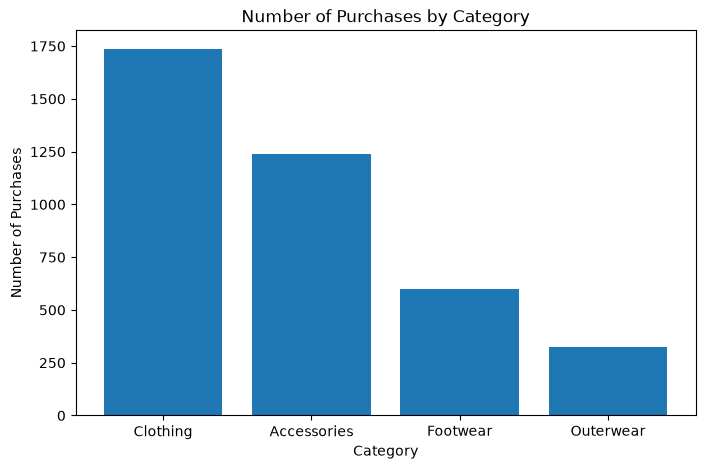

In [93]:
category_counts = clean_df["category"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(category_counts.index, category_counts.values)

plt.title("Number of Purchases by Category")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

plt.show()

#### Key Insights
##### Clothing has the highest number of purchases with 1,737.
##### Accessories comes second with 1,240 purchases.
##### Footwear has 599 purchases.
##### Outerwear has the lowest with 324 purchases.
##### This shows that Clothing is the dominant category by purchase volume, accounting for the largest share of transactions.
#### Recommended Action
##### The business should maintain strong inventory availability for Clothing and explore cross-selling opportunities between Clothing and Accessories. For Outerwear, targeted promotions or seasonal campaigns could help increase purchase volume.

### Visualization 2 — Season-wise Total Sales
##### 2. Which season generates the highest total sales?

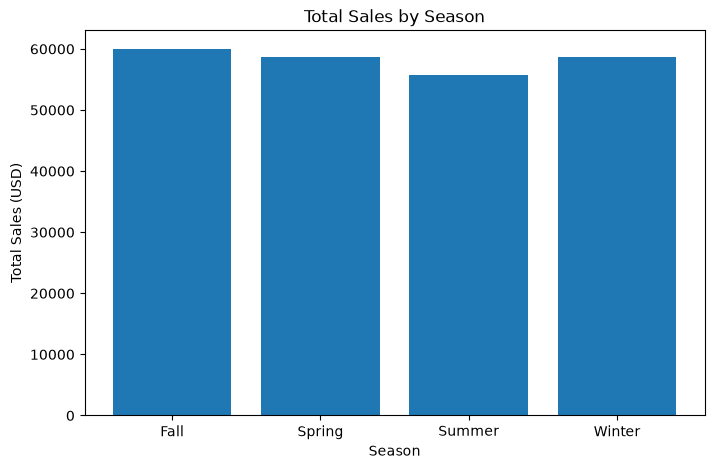

In [94]:
season_sales = clean_df.groupby("season")["purchase_amount_usd"].sum()

plt.figure(figsize=(8, 5))

plt.bar(
    season_sales.index,
    season_sales.values
)

plt.title("Total Sales by Season")
plt.xlabel("Season")
plt.ylabel("Total Sales (USD)")

plt.show()

#### Key Insights
##### Fall generates the highest total sales, at approximately 60,000 USD.
##### Spring and Winter are very close, at around 58,500–58,700 USD.
##### Summer has the lowest total sales, at approximately 55,500 USD.
##### Overall, the difference between seasons is relatively small, so sales are fairly consistent throughout the year.
#### Recommended Action
##### The business can maintain regular inventory throughout the year, while using Fall campaigns to maximize the strongest seasonal demand and Summer promotions to improve the comparatively lower sales.

### Visualization 3 — Purchase Amount Distribution
##### 3. How are customer purchase amounts distributed across the dataset?

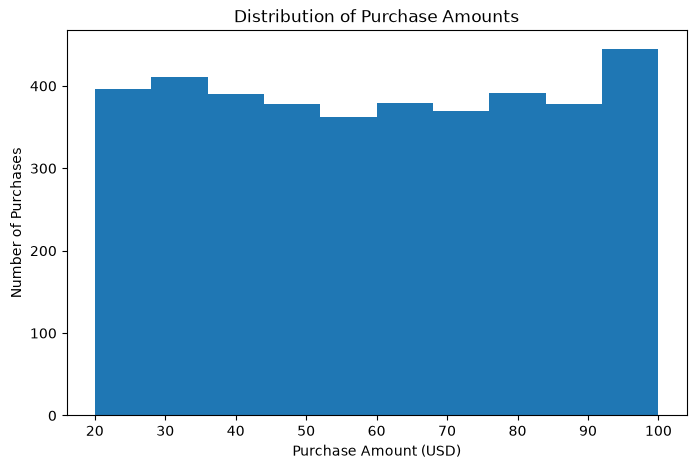

In [95]:
plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["purchase_amount_usd"],
    bins=10
)

plt.title("Distribution of Purchase Amounts")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Number of Purchases")

plt.show()

#### Key Inisghts
##### Purchase amounts range approximately from 20 to 100 USD.
##### The distribution is fairly spread across the entire range, rather than being concentrated in one narrow price range.
##### Purchases around 90–100 USD show the highest frequency in the chart.
##### Overall, customers purchase across a wide range of price points, indicating varied spending behavior.
#### Recommended Action
##### he business can maintain products across multiple price ranges instead of focusing on only one price segment. Premium products around the higher spending range can also be promoted to suitable customers.

### Visualization 4 — Age Group Distribution
##### 4. Which age groups contribute the most purchase records?

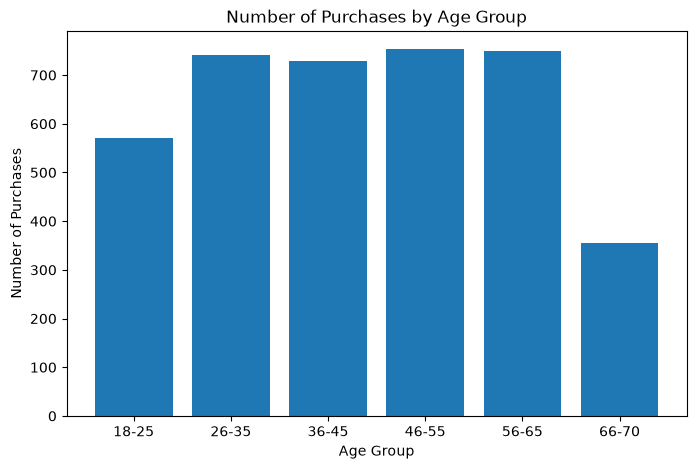

In [96]:
age_group_counts = clean_df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    age_group_counts.index,
    age_group_counts.values
)

plt.title("Number of Purchases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Purchases")

plt.show()

#### Key Insights
##### 46–55 age group has the highest number of purchases.
##### 56–65 and 26–35 are also among the highest.
##### 36–45 is slightly lower than these groups.
##### 18–25 has fewer purchases compared with the middle-age groups.
##### 66–70 has the lowest number of purchases.
#### Recommended Action
##### The business should focus its marketing efforts on the 26–65 age groups, especially the 46–55 and 56–65 segments, while using targeted offers to improve engagement among the 18–25 and 66–70 groups.

## SECTION D : Seaborn
### Visualization 5 — Purchase Amount by Category
##### 5. How does the purchase amount vary across different product categories?

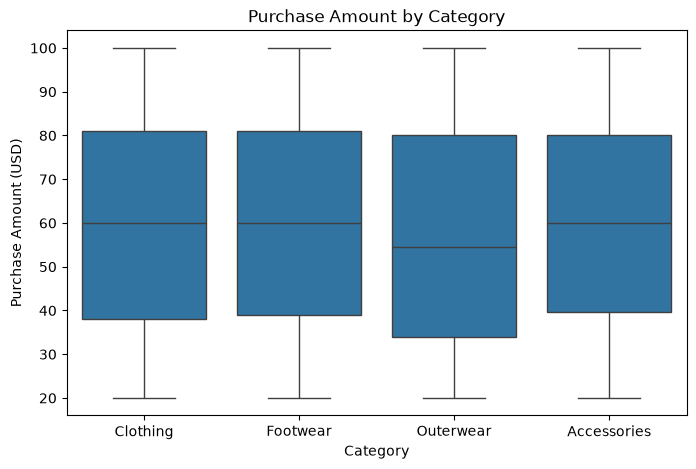

In [97]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="category",
    y="purchase_amount_usd",
    data=clean_df
)
plt.title("Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Purchase Amount (USD)")

plt.show()

#### Key Insights
##### Clothing, Footwear, and Accessories have a similar median purchase amount of around 60 USD.
##### Outerwear has a slightly lower median of around 55 USD.
##### Outerwear shows a slightly wider spread in purchase amounts compared with the other categories.
##### All categories have a similar overall range of approximately 20–100 USD.
##### There are no obvious outliers in the chart.
#### Recommended Action
##### Since the typical purchase value is fairly similar across categories, the business can maintain a balanced pricing strategy rather than relying on one category for higher-value purchases. Outerwear could be analyzed further to understand why its median spending is slightly lower.

### Visualization 6 — Subscription Status Distribution
##### 6. How many customers are subscribed versus non-subscribed?

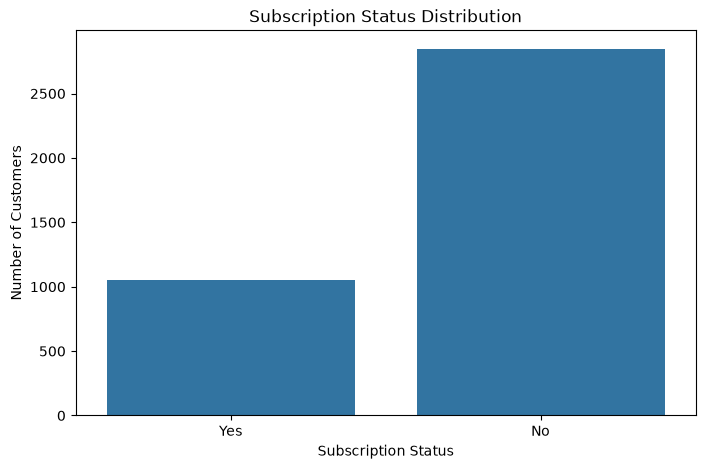

In [98]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="subscription_status",
    data=clean_df
)
plt.title("Subscription Status Distribution")
plt.xlabel("Subscription Status")
plt.ylabel("Number of Customers")

plt.show()

#### Key Insights
##### Non-subscribed customers are significantly higher than subscribed customers.
##### Around 2,800 customers are not subscribed.
##### Around 1,050 customers have a subscription.
##### This indicates that the majority of customers in the dataset are not enrolled in the subscription program.
#### Recommended Action
##### The business can focus on subscription conversion strategies, such as exclusive discounts, member-only benefits, or loyalty rewards, to encourage non-subscribed customers to become subscribers.

### Visualization 7 — Review Rating Distribution
##### 7. How are customer review ratings distributed?

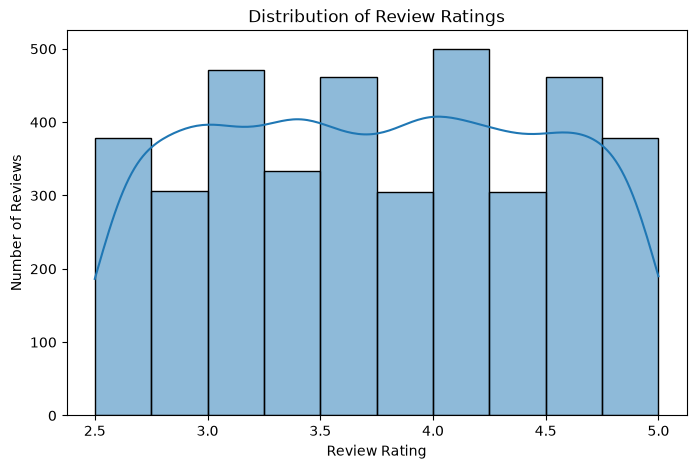

In [99]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["review_rating"],
    bins=10,
    kde=True
)
plt.title("Distribution of Review Ratings")
plt.xlabel("Review Rating")
plt.ylabel("Number of Reviews")

plt.show()

#### Key Insights
##### Review ratings range from approximately 2.5 to 5.0.
##### Ratings are fairly spread across the range, rather than being concentrated at only one rating.
##### The highest frequency is around the 4.0–4.2 range.
##### Ratings around 3.0–3.2 and 4.5–4.7 also have relatively high frequencies.
##### Overall, customer ratings are generally distributed across the mid-to-high rating range.
#### Recommended Action
##### The business should continue monitoring customer feedback, especially ratings below 3.5, to identify areas for product or service improvement. The relatively strong presence of ratings around 4.0 and above indicates generally positive customer feedback.

### Visualization 8 — Previous Purchases vs Purchase Amount
##### 8. Is there a relationship between previous purchases and the current purchase amount?

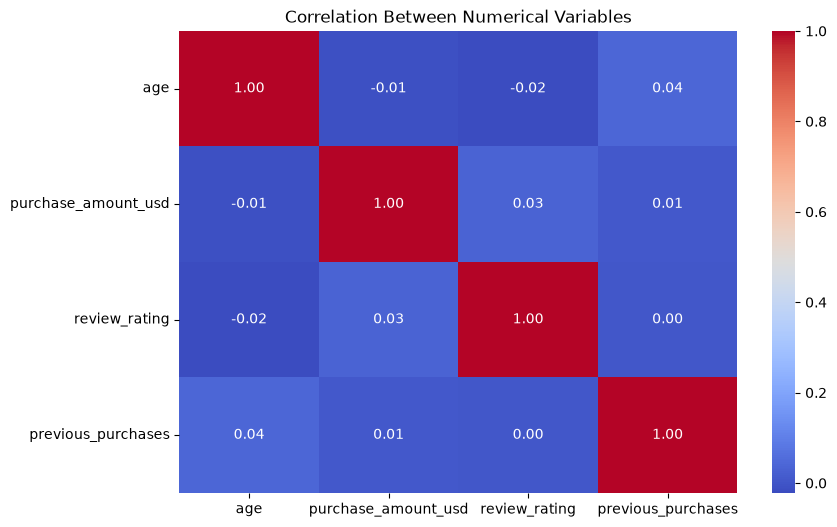

In [101]:
plt.figure(figsize=(9, 6))

correlation = clean_df[
    [
        "age",
        "purchase_amount_usd",
        "review_rating",
        "previous_purchases"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

#### Key Insights
##### Age vs Previous Purchases: very weak positive correlation (0.04).
##### Purchase Amount vs Review Rating: almost no relationship (0.03).
##### Age vs Purchase Amount: almost no relationship (-0.01).
##### Purchase Amount vs Previous Purchases: almost no relationship (0.01).
##### Overall, the numerical variables show very weak linear relationships with each other.
#### Recommended Action
##### The business should not depend on a single numerical variable to predict customer spending. A combination of factors such as category, season, subscription status, discounts, and customer demographics would provide more useful insights for customer analysis.

## Key Visualization Findings
### Category Distribution
##### - Clothing has the highest purchase volume.
##### - Outerwear has the lowest purchase volume.
##### - Business Insight: Focus inventory and promotions on high-demand categories.
#### Seasonal Sales
##### - Fall records the highest total sales.
##### - Summer records comparatively lower sales.
##### - Business Insight: Strengthen seasonal campaigns during high-performing periods and use promotions during weaker periods.
#### Purchase Amount Distribution
##### - Customers purchase across a broad price range.
##### - Higher purchase amounts are also frequently observed.
##### - Business Insight: Maintain products across different price segments.
#### Age Group Distribution
##### - Middle-aged customer groups contribute the highest purchase volume.
##### - The 66–70 group has the lowest purchase volume.
##### - Business Insight: Target the 26–65 age segments with focused marketing campaigns.
#### Purchase Amount by Category
##### - Most categories have similar median purchase amounts.
##### - Outerwear has a slightly lower median.
##### - Business Insight: Maintain balanced pricing across categories and investigate lower-value categories.
#### Subscription Status
##### - Non-subscribers significantly outnumber subscribers.
##### - Business Insight: Subscription conversion is a major growth opportunity.
#### Review Rating Distribution
##### - Ratings are spread from 2.5 to 5.0.
##### - Ratings around 4.0 and above are relatively strong.
##### - Business Insight: Maintain product quality while investigating lower-rated customer experiences.
#### Correlation Heatmap
##### - Numerical variables show very weak correlations.
##### - Purchase amount does not strongly depend on age, rating, or previous purchases.
##### - Business Insight: Customer behavior should be analyzed using multiple factors together, rather than relying on one numerical variable.
## Overall Business Conclusion
##### The Shopping Trends analysis shows that customer purchasing behavior varies mainly across product categories, seasons, age groups, and subscription status. Clothing has the highest purchase volume, while subscription adoption remains a major opportunity. Since numerical variables show weak correlations, businesses should use a multi-factor customer segmentation strategy to improve targeting, promotions, and sales performance.